# SMOTE — Handling Imbalanced Data

In [1]:
# importing libraries
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt

In [2]:
# imprting files
X_train = pd.read_csv('../data/X_train.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()

In [3]:
X_train.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Hour
0,0.139063,0.703422,2.238954,-1.724499,-2.151484,-2.577803,0.993668,3.565492,-1.785957,0.860122,...,-0.323810,-0.149574,-0.049333,0.278442,0.684735,-0.219028,-0.159167,0.037920,-0.049932,16
1,-0.208733,-0.046731,-1.315062,1.630783,0.597001,-0.038359,-0.404580,-0.965712,0.212249,0.735381,...,-0.067580,-0.238898,-0.946773,0.323904,0.515632,-0.713000,-0.266503,-0.017794,0.051058,22
2,-0.098039,0.498553,1.908801,0.021184,-2.087997,0.129310,1.161468,0.605244,-0.022371,0.180296,...,-0.210474,0.293609,1.095842,-0.044874,-1.689517,0.106098,0.007758,0.045164,-0.053068,11
3,-0.065359,0.078144,1.811257,0.316556,0.316751,3.880231,0.048454,1.020163,-0.734868,0.233651,...,-0.228032,0.138869,0.700422,0.174064,0.702997,-0.212523,-0.010018,-0.017740,-0.038006,1
4,0.027813,-0.648353,1.358817,-1.120881,0.550266,-1.547659,-1.194950,0.275448,-1.201843,0.212889,...,-0.361686,-0.340972,-0.636442,0.252758,-0.344160,-0.064282,-0.439622,0.062524,0.013095,8


In [6]:
 # Apply SMOTE ONLY to training data
# NEVER apply SMOTE to test data — it would leak information
# k_neighbors=5 means: for each fraud sample, look at its
# 5 nearest fraud neighbours and create synthetic points
# between them
smote = SMOTE(
    random_state=42,
    k_neighbors=5,
    sampling_strategy='auto'  # balance classes 50/50
)

In [8]:
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)


print("\nAfter SMOTE:")
print(Counter(y_train_sm))
print(f"Fraud ratio: {y_train_sm.mean()*100:.4f}%")
print(f"Total training samples: {len(X_train_sm)}")


After SMOTE:
Counter({0: 226602, 1: 226602})
Fraud ratio: 50.0000%
Total training samples: 453204


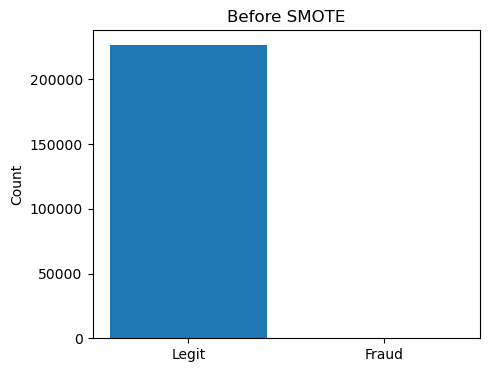

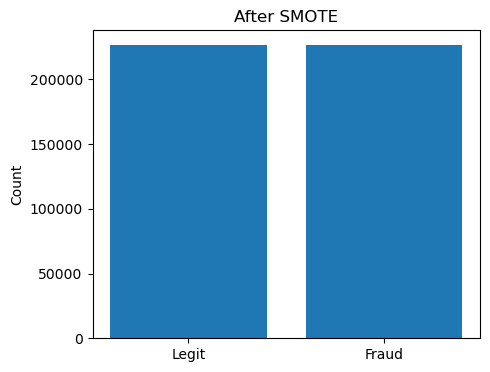

In [10]:
# Visualise before and after
import matplotlib.pyplot as plt
import pandas as pd

# Before SMOTE
before = pd.Series(y_train).value_counts()

plt.figure(figsize=(5,4))
plt.bar(['Legit', 'Fraud'], before.values)
plt.title("Before SMOTE")
plt.ylabel("Count")
plt.show()

# After SMOTE
after = pd.Series(y_train_sm).value_counts()

plt.figure(figsize=(5,4))
plt.bar(['Legit', 'Fraud'], after.values)
plt.title("After SMOTE")
plt.ylabel("Count")
plt.show()

In [11]:
# Save balanced training data
# Save X_train after SMOTE
pd.DataFrame(X_train_sm).to_csv(
    "../data/X_train_smote.csv",
    index=False
)

# Save y_train after SMOTE
pd.DataFrame(y_train_sm).to_csv(
    "../data/y_train_smote.csv",
    index=False
)

print("SMOTE data saved")

SMOTE data saved
